# 04 - Resultados de modelado

Este notebook interpreta entrenamientos existentes. No lanza `BayesSearchCV` ni predice sobre estrellas nuevas. La decision principal usa porcentaje de WR recuperadas en top 100.


## Conceptos usados

- `holdout`: test final separado por hash estable de `source_id` antes de reducir negativas.
- `CV`: cross-validation estratificada sobre train.
- `BayesSearchCV`: usa CV para buscar hiperparametros; no es redundante con reportar CV, porque luego se miden predicciones out-of-fold del mejor pipeline.
- `SMOTE` y `SMOTEENN`: se aplican despues de separar holdout y dentro de cada fold de train porque viven en una `imblearn.pipeline.Pipeline`.


In [16]:
from pathlib import Path
import sys
import json

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Force an interactive notebook backend when running cells manually.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass
from IPython.display import Markdown, Image, display

try:
    import seaborn as sns
except ImportError:
    sns = None

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})

PALETTE = {
    "xgboost": "#2F6F9F",
    "random_forest": "#3A9D5D",
    "hist_gradient_boosting": "#B7791F",
    "logistic_regression": "#7B61A8",
    "wr": "#A8324A",
    "candidate": "#2F6F9F",
    "negative": "#6B7280",
    "muted": "#6B7280",
}

def require_path(path):
    path = Path(path)
    if not path.is_absolute():
        path = ROOT / path
    if not path.exists():
        raise FileNotFoundError(path)
    return path

def pct(value):
    return "-" if pd.isna(value) else f"{100 * float(value):.1f}%"

def model_display(row):
    variant = str(row.get("dataset_variant", ""))
    family = "Relaxed" if variant.startswith("relaxed") else "Strict"
    dataset = variant.replace("relaxed_", "").replace("strict_", "")
    dataset = dataset.replace("photometry", "Phot").replace("parallax_soft", "Parallax+").replace("poe_", "POE>=")
    feat = "+err" if str(row.get("feature_set", "")).endswith("error") else "base"
    model = {"xgboost": "XGB", "random_forest": "RF", "hist_gradient_boosting": "HGB", "logistic_regression": "LogReg"}.get(str(row.get("model", "")), str(row.get("model", "")))
    sampler = {"smote": "SMOTE", "smote_enn": "SMOTE-ENN", "none": "sin sampler"}.get(str(row.get("sampler", "")), str(row.get("sampler", "")))
    return f"{model} {sampler} | {family} {dataset} | {feat}"

def add_model_columns(df):
    out = df.copy()
    out["model_label"] = out.apply(model_display, axis=1)
    for k in [50, 100, 500, 1000]:
        c = f"holdout_wr_at_{k}"
        if c in out.columns:
            out[f"{c}_pct"] = out[c] / out["wr_holdout"].replace(0, np.nan)
    return out

def rank_models(df, k=100):
    return df.sort_values(
        [f"holdout_wr_at_{k}_pct", "holdout_average_precision", "holdout_recall_at_100", "holdout_f2_wr"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)

results = add_model_columns(results)
ranked = rank_models(results, k=100)
print(f"Configuraciones evaluadas: {len(results)}")
print(f"Aceptadas: {int(results['selection_status'].eq('accepted').sum())}")
print("WR holdout por variante:")
display(results.drop_duplicates("dataset_variant").set_index("dataset_variant")["wr_holdout"].sort_index())


Configuraciones evaluadas: 64
Aceptadas: 17
WR holdout por variante:


dataset_variant
relaxed_parallax_soft    59
relaxed_photometry       68
relaxed_poe_2            46
relaxed_poe_3            41
strict_parallax_soft     54
strict_photometry        62
strict_poe_2             42
strict_poe_3             37
Name: wr_holdout, dtype: int64

## Seleccion de corrida

Esta seccion lista las corridas sincronizadas en `training_history.duckdb`. Define `TRAINING_RUN_ID` con una de las IDs disponibles para revisar un entrenamiento especifico.

In [17]:
from wr_detector.modeling.notebook_runs import available_training_runs, load_training_results_for_notebook

available_runs = available_training_runs(ROOT)
display(available_runs)

TRAINING_RUN_ID = "run_202606_science_v2"
results = load_training_results_for_notebook(ROOT, TRAINING_RUN_ID)
display(Markdown(f"**Corrida activa:** `{TRAINING_RUN_ID}` con `{len(results)}` resultados."))

,run_id,run_name,imported_at,notes,row_count,best_holdout_wr_at_50,best_holdout_wr_at_100,best_holdout_wr_at_500,best_holdout_average_precision,best_holdout_recall_at_fpr_0p005
0,run_202606_science_v2,train_models,2026-06-09T07:38:50.943846+00:00,None,96,35,44,60,0.567085,0.602941
1,run_20260608T194455984398Z_d1dee0800bd4,train_models,2026-06-08T19:44:55.971364+00:00,None,64,34,46,61,0.575756,0.588235


**Corrida activa:** `run_202606_science_v2` con `96` resultados.

In [18]:

# Enrich current results with dynamic top-k recovery and source-level diagnostics.
HISTORY_DB = ROOT / "data/databases/training_history.duckdb"
WR_DB = ROOT / "data/databases/wr_reference.duckdb"


def wr_family(value):
    text = "" if pd.isna(value) else str(value).upper().strip()
    if not text:
        return "unknown"
    if "WN" in text and "WC" in text:
        return "WN/WC"
    if "WO" in text:
        return "WO"
    if "WC" in text:
        return "WC"
    if "WN" in text:
        return "WN"
    return "other/unknown"


def load_wr_catalog():
    if not WR_DB.exists():
        return pd.DataFrame(columns=["source_id", "wr_id", "spectral_type", "wr_family"])
    con = duckdb.connect(str(WR_DB), read_only=True)
    try:
        wr = con.execute('SELECT source_id, wr_id, "Spectral Type" AS spectral_type FROM wr_reference').fetchdf()
    finally:
        con.close()
    wr["wr_family"] = wr["spectral_type"].map(wr_family)
    return wr


WR_CATALOG = load_wr_catalog()


def load_predictions_for_row(row):
    if HISTORY_DB.exists():
        con = duckdb.connect(str(HISTORY_DB), read_only=True)
        try:
            cols = {r[1] for r in con.execute("PRAGMA table_info('model_predictions')").fetchall()}
            if {"source_id", "row_id"}.issubset(cols):
                pred = con.execute('''
                    SELECT split, row_id, source_id, target, score, predicted, threshold
                    FROM model_predictions
                    WHERE run_id = ? AND dataset_variant = ? AND feature_set = ? AND model = ? AND sampler = ?
                ''', [TRAINING_RUN_ID, row.dataset_variant, row.feature_set, row.model, row.sampler]).fetchdf()
                if not pred.empty:
                    return pred
        finally:
            con.close()
    pred_path = ROOT / str(row.get("predictions_path", ""))
    if pred_path.exists():
        return pd.read_csv(pred_path)
    return pd.DataFrame()


def load_holdout_with_predictions(row):
    pred = load_predictions_for_row(row)
    if pred.empty or "source_id" not in pred.columns:
        return pd.DataFrame()
    hold_pred = pred[pred["split"].eq("holdout")].copy()
    data_path = ROOT / "data/processed/modeling" / f"{row.dataset_variant}_reduced.parquet"
    if not data_path.exists():
        return pd.DataFrame()
    data = pd.read_parquet(data_path)
    hold = data[data["modeling_split"].eq("holdout")].copy()
    joined = hold.merge(hold_pred[["source_id", "score", "predicted", "threshold"]], on="source_id", how="inner")
    if not WR_CATALOG.empty:
        joined = joined.merge(WR_CATALOG, on="source_id", how="left", suffixes=("", "_catalog"))
        if "wr_id_catalog" in joined.columns:
            joined["wr_id"] = joined["wr_id"].fillna(joined["wr_id_catalog"])
    joined["spectral_type"] = joined.get("spectral_type", pd.Series("unknown", index=joined.index)).fillna("unknown")
    joined["wr_family"] = joined.get("wr_family", pd.Series("unknown", index=joined.index)).fillna("unknown")
    joined["rank"] = joined["score"].rank(method="first", ascending=False).astype(int)
    return joined


def add_dynamic_topk(results_df, ks=(10, 50, 100)):
    out = results_df.copy()
    for k in ks:
        out[f"holdout_wr_at_{k}_dynamic"] = np.nan
        out[f"holdout_wr_at_{k}_pct_dynamic"] = np.nan
    for idx, row in out.iterrows():
        joined = load_holdout_with_predictions(row)
        if joined.empty:
            continue
        ordered = joined.sort_values("score", ascending=False)
        wr_total = max(int((joined["target"] == 1).sum()), 1)
        for k in ks:
            recovered = int((ordered.head(k)["target"] == 1).sum())
            out.loc[idx, f"holdout_wr_at_{k}_dynamic"] = recovered
            out.loc[idx, f"holdout_wr_at_{k}_pct_dynamic"] = recovered / wr_total
    for k in ks:
        base_count = f"holdout_wr_at_{k}"
        base_pct = f"holdout_wr_at_{k}_pct"
        dyn_count = f"holdout_wr_at_{k}_dynamic"
        dyn_pct = f"holdout_wr_at_{k}_pct_dynamic"
        if base_count not in out.columns:
            out[base_count] = out[dyn_count]
        else:
            out[base_count] = out[base_count].fillna(out[dyn_count])
        if base_pct not in out.columns:
            out[base_pct] = out[dyn_pct]
        else:
            out[base_pct] = out[base_pct].fillna(out[dyn_pct])
    return out


def parse_best_params(value):
    if isinstance(value, dict):
        params = value
    elif pd.isna(value) or value == "":
        params = {}
    else:
        try:
            params = json.loads(value)
        except (TypeError, json.JSONDecodeError):
            params = {}
    return {str(k).replace("estimator__", ""): v for k, v in params.items()}


IMPORTANT_HYPERPARAMS = [
    "n_estimators", "max_depth", "min_samples_leaf", "max_features",
    "learning_rate", "subsample", "colsample_bytree", "reg_lambda", "min_child_weight",
]


def compact_hyperparams(row):
    pieces = []
    if pd.notna(row.get("n_estimators", np.nan)):
        pieces.append(f"trees={int(row['n_estimators'])}")
    if pd.notna(row.get("max_depth", np.nan)):
        pieces.append(f"depth={row['max_depth']}")
    if pd.notna(row.get("learning_rate", np.nan)):
        pieces.append(f"eta={float(row['learning_rate']):.3f}")
    if pd.notna(row.get("min_samples_leaf", np.nan)):
        pieces.append(f"leaf={row['min_samples_leaf']}")
    if pd.notna(row.get("min_child_weight", np.nan)):
        pieces.append(f"child={row['min_child_weight']}")
    if pd.notna(row.get("subsample", np.nan)):
        pieces.append(f"sub={float(row['subsample']):.2f}")
    if pd.notna(row.get("colsample_bytree", np.nan)):
        pieces.append(f"col={float(row['colsample_bytree']):.2f}")
    if pd.notna(row.get("reg_lambda", np.nan)):
        pieces.append(f"lambda={float(row['reg_lambda']):.2f}")
    return " | ".join(pieces) if pieces else "sin params"


def add_hyperparameter_columns(results_df):
    out = results_df.copy()
    parsed = out.get("bayes_best_params", pd.Series([{}] * len(out), index=out.index)).map(parse_best_params)
    numeric_params = [name for name in IMPORTANT_HYPERPARAMS if name != "max_features"]
    for name in IMPORTANT_HYPERPARAMS:
        out[name] = parsed.map(lambda params, n=name: params.get(n, np.nan))
        if name in numeric_params:
            out[name] = pd.to_numeric(out[name], errors="coerce")
    out["hyperparams_compact"] = out.apply(compact_hyperparams, axis=1)
    out["overfit_warning_flag"] = out["selection_status"].eq("overfit_warning")
    return out


results = add_hyperparameter_columns(results)
results = add_dynamic_topk(results, ks=(10, 50, 100))
ranked = rank_models(results, k=100)


## Ranking principal: WR recuperadas en top 100


In [19]:
cols = [
    "model_label", "n_train", "wr_train", "n_holdout", "wr_holdout",
    "holdout_wr_at_100", "holdout_wr_at_100_pct", "holdout_average_precision",
    "holdout_f2_wr", "holdout_precision_wr", "holdout_recall_wr", "selection_status",
]
display(ranked[cols].head(15).style.format({
    "holdout_wr_at_100_pct": "{:.1%}",
    "holdout_average_precision": "{:.3f}",
    "holdout_f2_wr": "{:.3f}",
    "holdout_precision_wr": "{:.3f}",
    "holdout_recall_wr": "{:.3f}",
}))

fig, ax = plt.subplots(figsize=(11.5, 7))
plot = ranked.head(15).iloc[::-1]
colors = [PALETTE.get(m, PALETTE["muted"]) for m in plot["model"]]
ax.barh(plot["model_label"], 100 * plot["holdout_wr_at_100_pct"], color=colors)
for i, row in enumerate(plot.itertuples()):
    ax.text(100 * row.holdout_wr_at_100_pct + 1, i, f"{int(row.holdout_wr_at_100)}/{int(row.wr_holdout)}", va="center", fontsize=9)
ax.set_xlabel("WR recuperadas en top 100 / WR holdout (%)")
ax.set_title("Mejores configuraciones por porcentaje de recuperacion en top 100")
plt.tight_layout()
plt.show()


KeyError: "['model_label'] not in index"

## Hiperparametros y complejidad arborea

Los hiperparametros vienen de `BayesSearchCV`. No cambian los IDs ni los artefactos; aqui solo se extraen para auditar complejidad. El numero de arboles ayuda a leer capacidad, pero el indicador de sobreajuste sigue siendo el gap `train - CV` y la estabilidad `holdout - CV`.

,model_label,n_train,wr_train,n_holdout,wr_holdout,holdout_wr_at_10_pct,holdout_wr_at_50_pct,holdout_wr_at_100_pct,holdout_average_precision,cv_train_gap_f2,holdout_cv_gap_f2,selection_status,hyperparams_compact
0,XGB SMOTE | Strict Phot | +err,2503,226,6125,62,11.3%,43.5%,74.2%,0.508,0.214,-0.011,overfit_warning,trees=100 | depth=7 | eta=0.111 | child=1.0 | sub=0.69 | col=0.60 | lambda=0.10
1,XGB SMOTE | Strict POE>=2 | +err,1650,150,4081,42,21.4%,54.8%,73.8%,0.576,0.121,0.004,accepted,trees=289 | depth=8 | eta=0.160 | child=1.0 | sub=0.66 | col=1.00 | lambda=20.00
2,XGB SMOTE | Strict POE>=3 | +err,1496,136,4197,37,13.5%,54.1%,73.0%,0.396,0.137,0.003,accepted,trees=261 | depth=4 | eta=0.147 | child=1.0 | sub=0.60 | col=0.60 | lambda=20.00
3,XGB SMOTE-ENN | Strict POE>=3 | base,1496,136,4197,37,10.8%,51.4%,73.0%,0.278,0.038,0.030,cv_precision_floor_not_met,trees=268 | depth=7 | eta=0.101 | child=6.0 | sub=0.96 | col=0.63 | lambda=0.56
4,XGB SMOTE | Strict Parallax+ | +err,2134,194,5191,54,9.3%,50.0%,72.2%,0.441,0.184,-0.003,overfit_warning,trees=389 | depth=8 | eta=0.200 | child=1.0 | sub=0.79 | col=1.00 | lambda=20.00
5,RF SMOTE | Relaxed POE>=2 | base,1991,181,4337,46,8.7%,52.2%,71.7%,0.376,0.311,0.003,holdout_precision_floor_not_met,trees=378 | depth=11 | leaf=2.0
6,XGB SMOTE-ENN | Strict POE>=2 | base,1650,150,4081,42,14.3%,50.0%,71.4%,0.428,-0.008,0.119,accepted,trees=400 | depth=7 | eta=0.200 | child=3.0 | sub=0.63 | col=0.77 | lambda=0.49
7,RF SMOTE | Strict POE>=2 | +err,1650,150,4081,42,19.0%,50.0%,71.4%,0.426,0.214,-0.006,holdout_precision_floor_not_met,trees=400 | depth=11 | leaf=2.0
8,XGB SMOTE | Strict Phot | base,2503,226,6125,62,12.9%,46.8%,71.0%,0.518,0.280,-0.014,overfit_warning,trees=100 | depth=8 | eta=0.085 | child=1.0 | sub=0.68 | col=0.60 | lambda=0.17
9,XGB SMOTE | Strict POE>=3 | base,1496,136,4197,37,18.9%,54.1%,70.3%,0.434,0.073,0.054,accepted,trees=100 | depth=2 | eta=0.200 | child=2.0 | sub=0.60 | col=0.60 | lambda=0.10


,configs,n_estimators_mean,n_estimators_median,n_estimators_min,n_estimators_max,max_depth_mean,max_depth_median,cv_train_gap_f2_mean,cv_train_gap_f2_median,holdout_cv_gap_f2_mean,holdout_ap_mean,overfit_warning_rate
model,,,,,,,,,,,,
xgboost,32,264.8,274,100,400,6.3,7,0.102,0.102,0.024,0.407,21.9%
random_forest,32,303.0,348,100,400,13.1,14,0.168,0.171,-0.015,0.357,21.9%


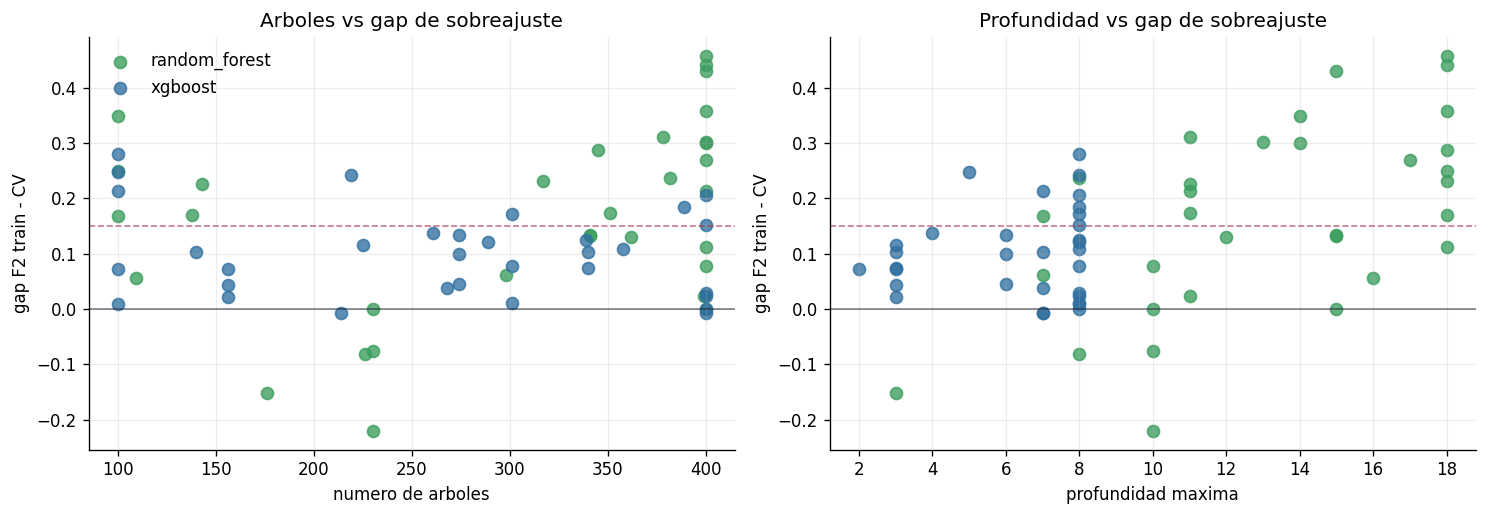

In [ ]:

param_cols = [
    "model_label", "n_train", "wr_train", "n_holdout", "wr_holdout",
    "holdout_wr_at_10_pct", "holdout_wr_at_50_pct", "holdout_wr_at_100_pct",
    "holdout_average_precision", "cv_train_gap_f2", "holdout_cv_gap_f2", "selection_status",
    "hyperparams_compact",
]
display(ranked[param_cols].head(15).style.format({
    "holdout_wr_at_10_pct": "{:.1%}",
    "holdout_wr_at_50_pct": "{:.1%}",
    "holdout_wr_at_100_pct": "{:.1%}",
    "holdout_average_precision": "{:.3f}",
    "cv_train_gap_f2": "{:.3f}",
    "holdout_cv_gap_f2": "{:.3f}",
}))

tree_stats = (
    results.groupby("model", dropna=False)
    .agg(
        configs=("model_label", "size"),
        n_estimators_mean=("n_estimators", "mean"),
        n_estimators_median=("n_estimators", "median"),
        n_estimators_min=("n_estimators", "min"),
        n_estimators_max=("n_estimators", "max"),
        max_depth_mean=("max_depth", "mean"),
        max_depth_median=("max_depth", "median"),
        cv_train_gap_f2_mean=("cv_train_gap_f2", "mean"),
        cv_train_gap_f2_median=("cv_train_gap_f2", "median"),
        holdout_cv_gap_f2_mean=("holdout_cv_gap_f2", "mean"),
        holdout_ap_mean=("holdout_average_precision", "mean"),
        overfit_warning_rate=("overfit_warning_flag", "mean"),
    )
    .sort_values("holdout_ap_mean", ascending=False)
)
display(tree_stats.style.format({
    "n_estimators_mean": "{:.1f}",
    "n_estimators_median": "{:.0f}",
    "n_estimators_min": "{:.0f}",
    "n_estimators_max": "{:.0f}",
    "max_depth_mean": "{:.1f}",
    "max_depth_median": "{:.0f}",
    "cv_train_gap_f2_mean": "{:.3f}",
    "cv_train_gap_f2_median": "{:.3f}",
    "holdout_cv_gap_f2_mean": "{:.3f}",
    "holdout_ap_mean": "{:.3f}",
    "overfit_warning_rate": "{:.1%}",
}))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for model_name, group in results.dropna(subset=["n_estimators"]).groupby("model"):
    color = PALETTE.get(model_name, PALETTE["muted"])
    axes[0].scatter(group["n_estimators"], group["cv_train_gap_f2"], s=52, alpha=0.78, color=color, label=model_name)
    axes[1].scatter(group["max_depth"], group["cv_train_gap_f2"], s=52, alpha=0.78, color=color, label=model_name)
for ax in axes:
    ax.axhline(0, color="#111827", lw=1, alpha=0.55)
    ax.axhline(0.15, color="#A8324A", lw=1, ls="--", alpha=0.65)
    ax.set_ylabel("gap F2 train - CV")
axes[0].set_xlabel("numero de arboles")
axes[1].set_xlabel("profundidad maxima")
axes[0].set_title("Arboles vs gap de sobreajuste")
axes[1].set_title("Profundidad vs gap de sobreajuste")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()


## Top actual


In [ ]:
for idx, row in ranked.head(3).reset_index(drop=True).iterrows():
    display(Markdown(
        f"**#{idx+1}: {row['model_label']}**  \n"
        f"- top 100: `{int(row['holdout_wr_at_100'])}/{int(row['wr_holdout'])}` = `{pct(row['holdout_wr_at_100_pct'])}`  \n"
        f"- train: `{int(row['n_train'])}` filas, `{int(row['wr_train'])}` WR  \n"
        f"- holdout/test: `{int(row['n_holdout'])}` filas, `{int(row['wr_holdout'])}` WR  \n"
        f"- AP holdout: `{row['holdout_average_precision']:.3f}`; F2 holdout: `{row['holdout_f2_wr']:.3f}`; estado: `{row['selection_status']}`"
    ))


**#1: XGB SMOTE | Strict Phot | +err**  
- top 100: `46/62` = `74.2%`  
- train: `2503` filas, `226` WR  
- holdout/test: `6125` filas, `62` WR  
- AP holdout: `0.508`; F2 holdout: `0.562`; estado: `overfit_warning`

**#2: XGB SMOTE | Strict POE>=2 | +err**  
- top 100: `31/42` = `73.8%`  
- train: `1650` filas, `150` WR  
- holdout/test: `4081` filas, `42` WR  
- AP holdout: `0.576`; F2 holdout: `0.529`; estado: `accepted`

**#3: XGB SMOTE | Strict POE>=3 | +err**  
- top 100: `27/37` = `73.0%`  
- train: `1496` filas, `136` WR  
- holdout/test: `4197` filas, `37` WR  
- AP holdout: `0.396`; F2 holdout: `0.421`; estado: `accepted`

## Ranking por presupuesto de revision


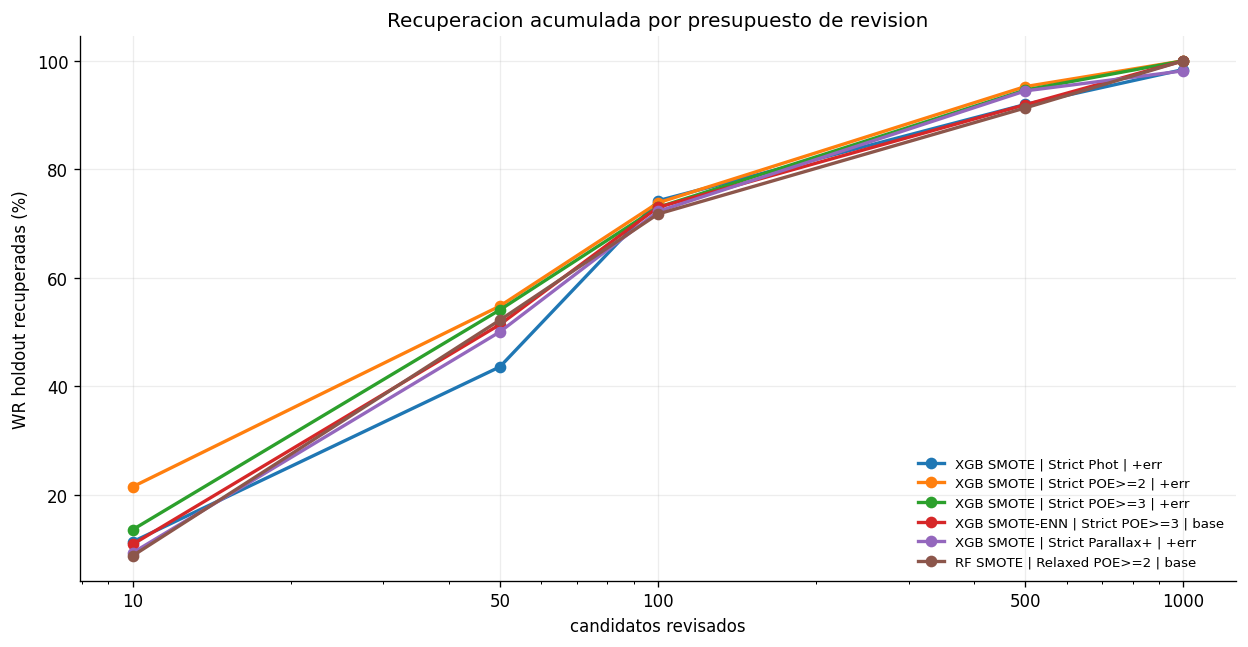

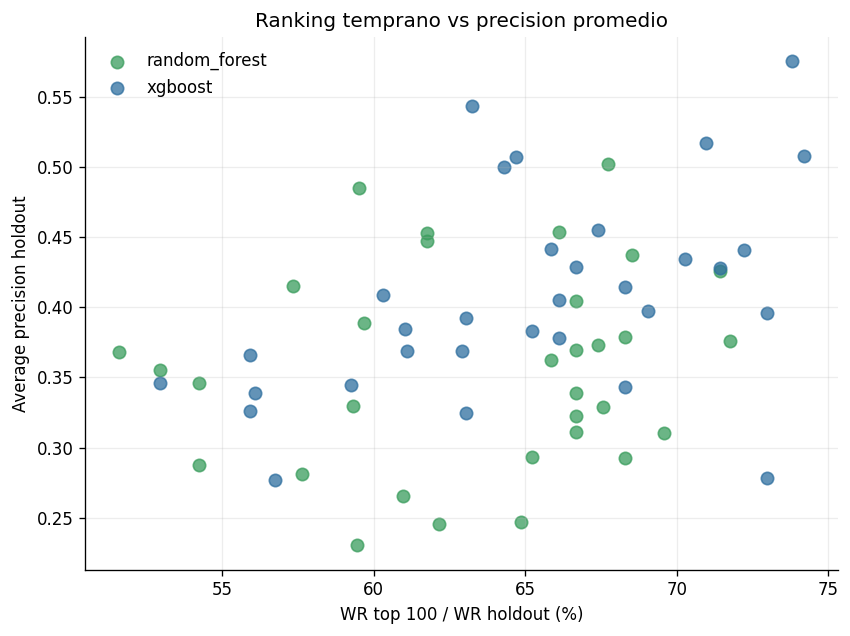

In [ ]:
ks = [10, 50, 100, 500, 1000]
top = ranked.head(6)
fig, ax = plt.subplots(figsize=(10.5, 5.5))
for _, row in top.iterrows():
    ax.plot(ks, [100 * row.get(f"holdout_wr_at_{k}_pct", np.nan) for k in ks], marker="o", lw=2, label=row["model_label"])
ax.set_xscale("log")
ax.set_xticks(ks, labels=[str(k) for k in ks])
ax.set_ylabel("WR holdout recuperadas (%)")
ax.set_xlabel("candidatos revisados")
ax.set_title("Recuperacion acumulada por presupuesto de revision")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 5.4))
for model, group in results.groupby("model"):
    ax.scatter(100 * group["holdout_wr_at_100_pct"], group["holdout_average_precision"], s=55, alpha=0.75, label=model, color=PALETTE.get(model, PALETTE["muted"]))
ax.set_xlabel("WR top 100 / WR holdout (%)")
ax.set_ylabel("Average precision holdout")
ax.set_title("Ranking temprano vs precision promedio")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Desempeno por familia de dataset


,best_top100_pct,best_ap,wr_holdout,n_holdout,configs
dataset_variant,,,,,
strict_photometry,74.2%,0.518,62,6125,8
strict_poe_2,73.8%,0.576,42,4081,8
strict_poe_3,73.0%,0.434,37,4197,8
strict_parallax_soft,72.2%,0.441,54,5191,8
relaxed_poe_2,71.7%,0.455,46,4337,8
relaxed_poe_3,68.3%,0.442,41,4265,8
relaxed_parallax_soft,66.1%,0.405,59,6045,8
relaxed_photometry,64.7%,0.544,68,6626,8


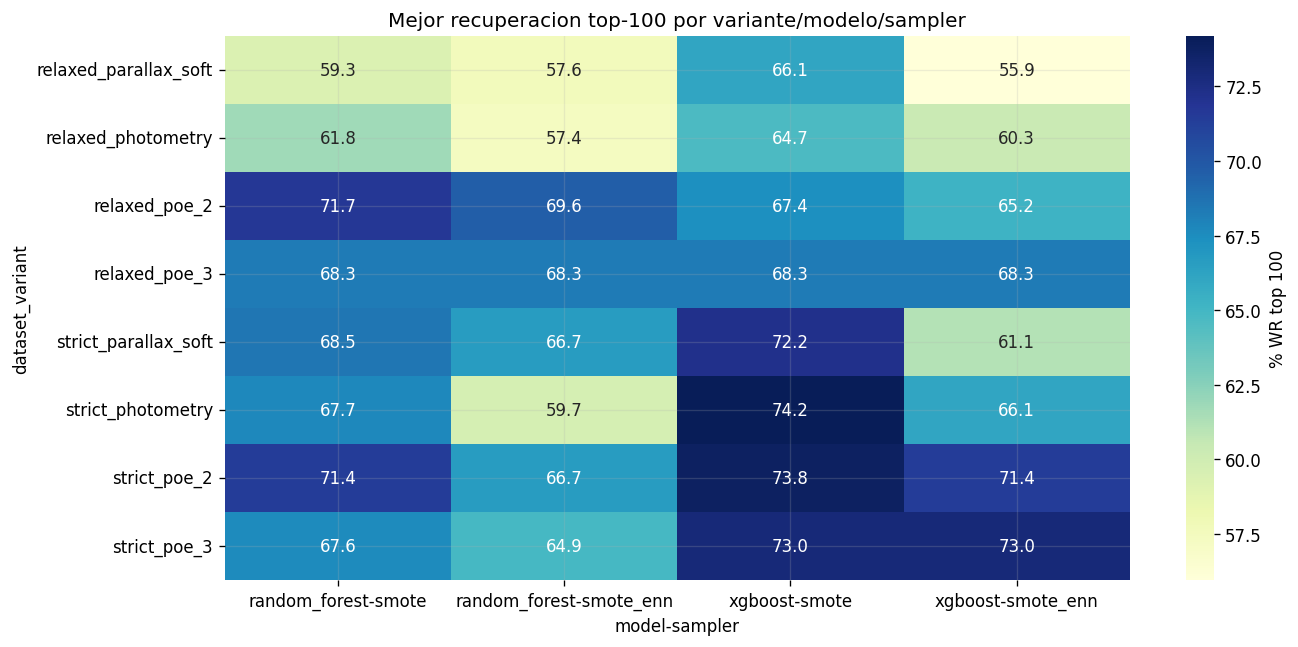

In [ ]:
variant_summary = ranked.groupby("dataset_variant").agg(
    best_top100_pct=("holdout_wr_at_100_pct", "max"),
    best_ap=("holdout_average_precision", "max"),
    wr_holdout=("wr_holdout", "first"),
    n_holdout=("n_holdout", "first"),
    configs=("model", "size"),
).sort_values("best_top100_pct", ascending=False)
display(variant_summary.style.format({"best_top100_pct": "{:.1%}", "best_ap": "{:.3f}"}))

heat = results.pivot_table(index="dataset_variant", columns=["model", "sampler"], values="holdout_wr_at_100_pct", aggfunc="max")
fig, ax = plt.subplots(figsize=(11.5, 5.5))
if sns:
    sns.heatmap(100 * heat, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "% WR top 100"})
else:
    im = ax.imshow((100 * heat).fillna(0), cmap="YlGnBu")
    ax.set_xticks(range(len(heat.columns)), [" / ".join(c) for c in heat.columns], rotation=35, ha="right")
    ax.set_yticks(range(len(heat.index)), heat.index)
    plt.colorbar(im, ax=ax, label="% WR top 100")
ax.set_title("Mejor recuperacion top-100 por variante/modelo/sampler")
plt.tight_layout()
plt.show()


## Diagnostico rapido de sobreajuste


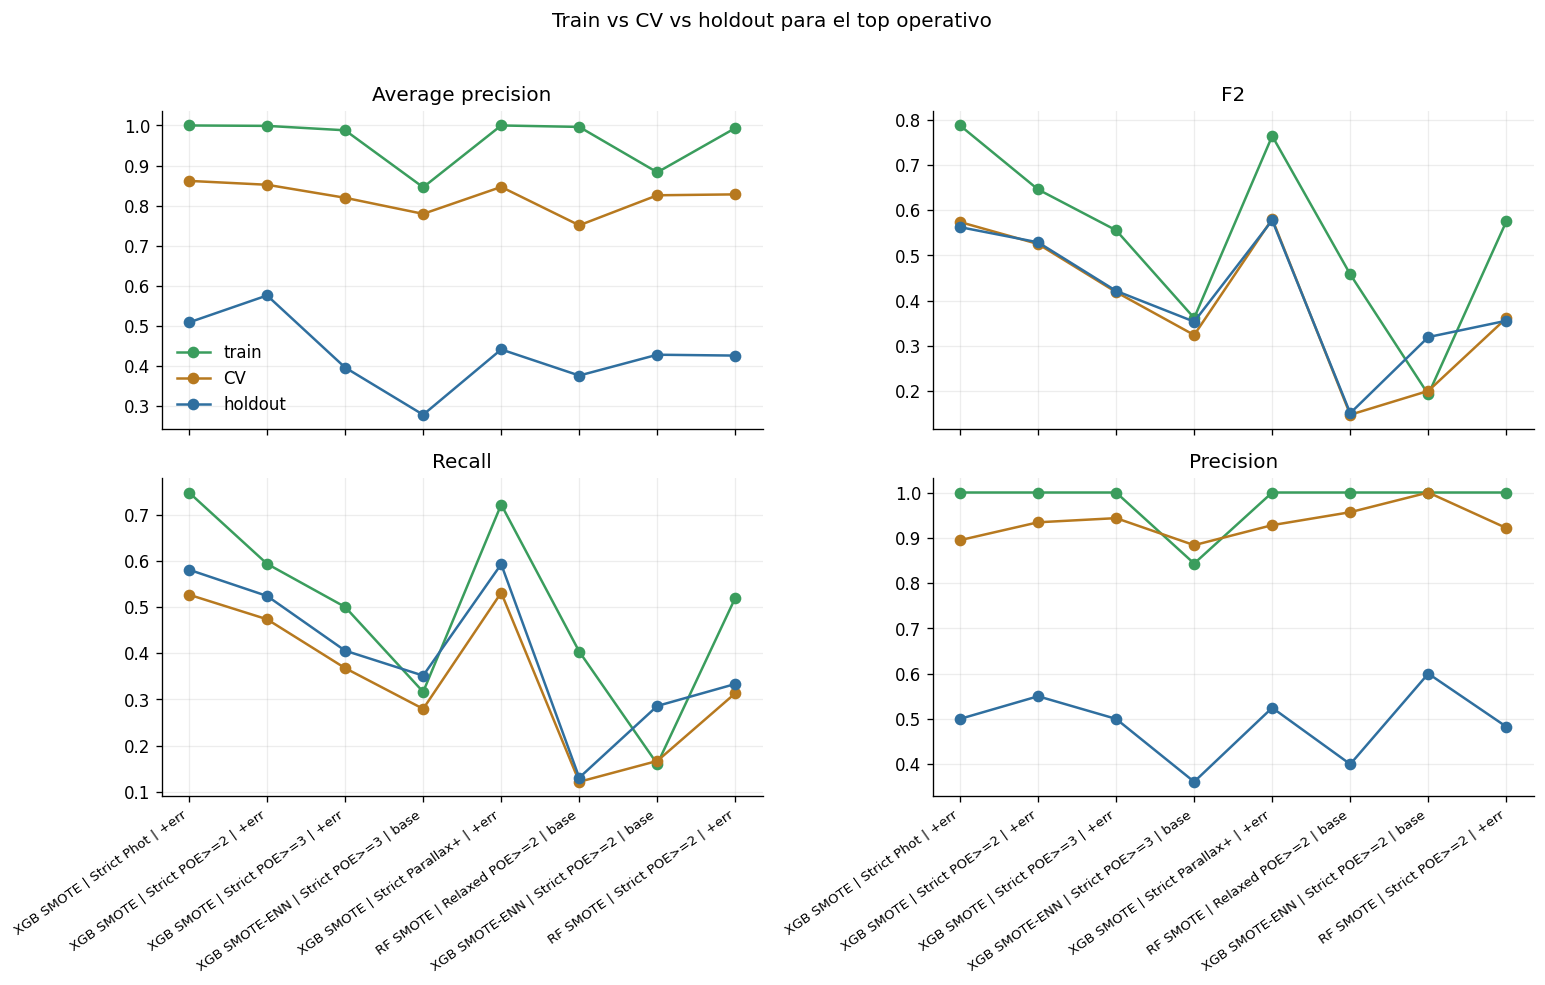

In [ ]:
metrics = ["average_precision", "f2_wr", "recall_wr", "precision_wr"]
labels = ["Average precision", "F2", "Recall", "Precision"]
top = ranked.head(8)
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, metric, label in zip(axes.ravel(), metrics, labels):
    x = np.arange(len(top))
    ax.plot(x, top[f"train_{metric}"], marker="o", label="train", color="#3A9D5D")
    ax.plot(x, top[f"cv_{metric}"], marker="o", label="CV", color="#B7791F")
    ax.plot(x, top[f"holdout_{metric}"], marker="o", label="holdout", color="#2F6F9F")
    ax.set_title(label)
    ax.set_xticks(x, top["model_label"], rotation=35, ha="right", fontsize=8)
axes[0, 0].legend(frameon=False)
fig.suptitle("Train vs CV vs holdout para el top operativo", y=1.02)
plt.tight_layout()
plt.show()


## Tipos SIMBAD confundidos como WR

Esta seccion mira falsos positivos del holdout: estrellas SIMBAD no-WR que el modelo marco como WR en el umbral seleccionado. Se agrupan por `simbad_main_type` y `simbad_query_type` para entender las clases contaminantes.

,model_label,dataset_variant,model,sampler,field,type,false_positive_rows,total_false_positives,share_of_fp
0,XGB SMOTE | Strict Phot | +err,strict_photometry,xgboost,smote,simbad_main_type,Em*,16,36,44.4%
1,XGB SMOTE | Strict Phot | +err,strict_photometry,xgboost,smote,simbad_main_type,Be*,6,36,16.7%
2,XGB SMOTE | Strict Phot | +err,strict_photometry,xgboost,smote,simbad_main_type,HXB,5,36,13.9%
3,XGB SMOTE | Strict Phot | +err,strict_photometry,xgboost,smote,simbad_main_type,Y*O,4,36,11.1%
4,XGB SMOTE | Strict Phot | +err,strict_photometry,xgboost,smote,simbad_main_type,AB*,4,36,11.1%
5,XGB SMOTE | Strict Phot | +err,strict_photometry,xgboost,smote,simbad_main_type,LP*,1,36,2.8%
6,XGB SMOTE | Strict Phot | +err,strict_photometry,xgboost,smote,simbad_query_type,EmLine*,16,36,44.4%
7,XGB SMOTE | Strict Phot | +err,strict_photometry,xgboost,smote,simbad_query_type,Be*,6,36,16.7%
8,XGB SMOTE | Strict Phot | +err,strict_photometry,xgboost,smote,simbad_query_type,HighMassXBin,5,36,13.9%
9,XGB SMOTE | Strict Phot | +err,strict_photometry,xgboost,smote,simbad_query_type,YSO,4,36,11.1%


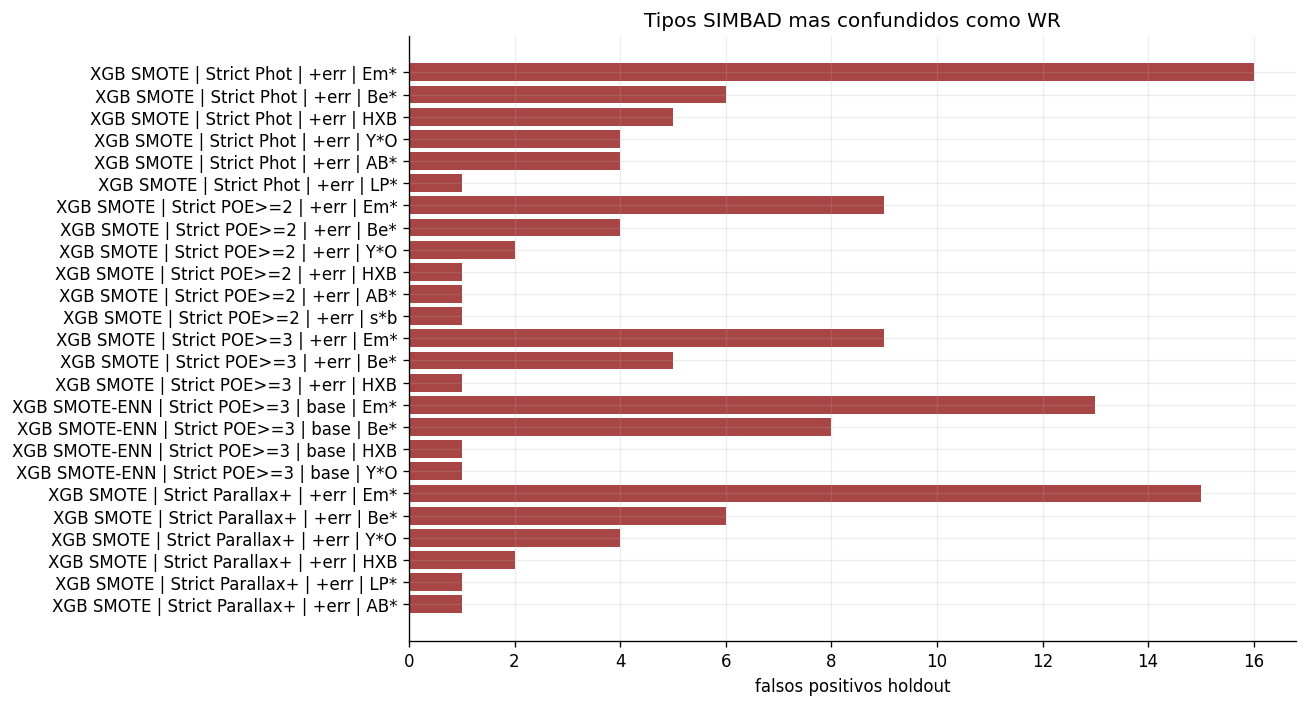

In [ ]:

rows = []
for _, row in ranked.head(10).iterrows():
    joined = load_holdout_with_predictions(row)
    if joined.empty:
        continue
    fp = joined[(joined["target"].eq(0)) & (joined["predicted"].eq(1))].copy()
    for col in ["simbad_main_type", "simbad_query_type"]:
        if col not in fp.columns:
            continue
        counts = fp[col].fillna("missing").value_counts().head(12)
        for label, count in counts.items():
            rows.append({
                "model_label": row["model_label"],
                "dataset_variant": row["dataset_variant"],
                "model": row["model"],
                "sampler": row["sampler"],
                "field": col,
                "type": label,
                "false_positive_rows": int(count),
                "total_false_positives": int(len(fp)),
                "share_of_fp": int(count) / max(len(fp), 1),
            })

fp_types = pd.DataFrame(rows)
if fp_types.empty:
    display(Markdown("No hay falsos positivos trazables para los modelos seleccionados."))
else:
    display(fp_types.style.format({"share_of_fp": "{:.1%}"}))
    plot = fp_types[fp_types["field"].eq("simbad_main_type")].head(25).iloc[::-1]
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.barh(plot["model_label"] + " | " + plot["type"].astype(str), plot["false_positive_rows"], color="#A84545")
    ax.set_xlabel("falsos positivos holdout")
    ax.set_title("Tipos SIMBAD mas confundidos como WR")
    plt.tight_layout()
    plt.show()


## Subtipos WR menos reconocidos

El subtipo se toma del catalogo de Crowther/GWRC (`Spectral Type` en `wr_reference.duckdb`) cruzado por `source_id`. Se reporta recuperacion por familia WR y por subtipo espectral exacto en el holdout.

**Familias WR menos reconocidas por modelo top:**

,model_label,dataset_variant,wr_type,wr_holdout,wr_recovered,median_score,recall_at_threshold
5,XGB SMOTE | Strict POE>=2 | +err,strict_poe_2,WO,2,0,0.509,0.0%
14,XGB SMOTE | Strict Parallax+ | +err,strict_parallax_soft,WO,2,0,0.519,0.0%
8,XGB SMOTE | Strict POE>=3 | +err,strict_poe_3,WO,2,0,0.541,0.0%
20,XGB SMOTE-ENN | Strict POE>=2 | base,strict_poe_2,WO,2,0,0.565,0.0%
23,RF SMOTE | Strict POE>=2 | +err,strict_poe_2,WO,2,0,0.578,0.0%
29,XGB SMOTE | Strict POE>=3 | base,strict_poe_3,WO,2,0,0.600,0.0%
11,XGB SMOTE-ENN | Strict POE>=3 | base,strict_poe_3,WO,2,0,0.638,0.0%
17,RF SMOTE | Relaxed POE>=2 | base,relaxed_poe_2,WO,2,0,0.651,0.0%
16,RF SMOTE | Relaxed POE>=2 | base,relaxed_poe_2,WN,33,4,0.899,12.1%
15,RF SMOTE | Relaxed POE>=2 | base,relaxed_poe_2,WC,11,2,0.942,18.2%


**Subtipos espectrales exactos menos reconocidos (minimo 2 objetos en holdout del modelo):**

,model_label,dataset_variant,wr_type,wr_holdout,wr_recovered,median_score,recall_at_threshold
194,RF SMOTE | Relaxed POE>=2 | base,relaxed_poe_2,WN6o,3,0,0.506,0.0%
226,XGB SMOTE-ENN | Strict POE>=2 | base,strict_poe_2,WN6o,3,0,0.571,0.0%
180,RF SMOTE | Relaxed POE>=2 | base,relaxed_poe_2,WC9,3,0,0.957,0.0%
214,XGB SMOTE-ENN | Strict POE>=2 | base,strict_poe_2,WC9,3,0,0.999,0.0%
305,XGB SMOTE | Strict Phot | base,strict_photometry,WN8h,2,0,0.675,0.0%
242,RF SMOTE | Strict POE>=2 | +err,strict_poe_2,WC6,2,0,0.876,0.0%
176,RF SMOTE | Relaxed POE>=2 | base,relaxed_poe_2,WC6,2,0,0.909,0.0%
188,RF SMOTE | Relaxed POE>=2 | base,relaxed_poe_2,WN5o,5,1,0.974,20.0%
62,XGB SMOTE | Strict POE>=2 | +err,strict_poe_2,WN6o,3,1,0.572,33.3%
257,RF SMOTE | Strict POE>=2 | +err,strict_poe_2,WN6o,3,1,0.642,33.3%


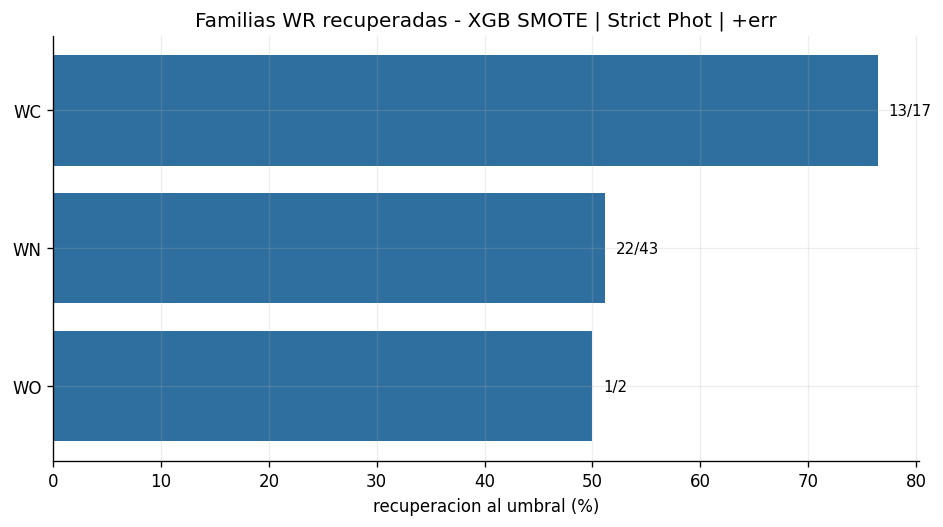

In [ ]:

subtype_rows = []
family_rows = []
for _, row in ranked.head(10).iterrows():
    joined = load_holdout_with_predictions(row)
    if joined.empty:
        continue
    wr_holdout = joined[joined["target"].eq(1)].copy()
    if wr_holdout.empty:
        continue
    for group_col, collector in [("wr_family", family_rows), ("spectral_type", subtype_rows)]:
        grouped = wr_holdout.groupby(group_col, dropna=False).agg(
            wr_holdout=("source_id", "size"),
            wr_recovered=("predicted", "sum"),
            median_score=("score", "median"),
        ).reset_index().rename(columns={group_col: "wr_type"})
        grouped["recall_at_threshold"] = grouped["wr_recovered"] / grouped["wr_holdout"].replace(0, np.nan)
        grouped.insert(0, "model_label", row["model_label"])
        grouped.insert(1, "dataset_variant", row["dataset_variant"])
        collector.extend(grouped.to_dict("records"))

family_recovery = pd.DataFrame(family_rows)
subtype_recovery = pd.DataFrame(subtype_rows)
if family_recovery.empty:
    display(Markdown("No hay WR de holdout trazables a subtipo espectral."))
else:
    display(Markdown("**Familias WR menos reconocidas por modelo top:**"))
    display(
        family_recovery.sort_values(["recall_at_threshold", "wr_holdout", "median_score"], ascending=[True, False, True])
        .head(30)
        .style.format({"recall_at_threshold": "{:.1%}", "median_score": "{:.3f}"})
    )
    display(Markdown("**Subtipos espectrales exactos menos reconocidos (minimo 2 objetos en holdout del modelo):**"))
    subtype_view = subtype_recovery[subtype_recovery["wr_holdout"].ge(2)].sort_values(
        ["recall_at_threshold", "wr_holdout", "median_score"], ascending=[True, False, True]
    ).head(30)
    display(subtype_view.style.format({"recall_at_threshold": "{:.1%}", "median_score": "{:.3f}"}))

    top_model = ranked.iloc[0]
    top_family = family_recovery[family_recovery["model_label"].eq(top_model["model_label"])]
    if not top_family.empty:
        plot = top_family.sort_values("recall_at_threshold")
        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.barh(plot["wr_type"].astype(str), 100 * plot["recall_at_threshold"], color="#2F6F9F")
        for i, r in enumerate(plot.itertuples(index=False)):
            ax.text(100 * r.recall_at_threshold + 1, i, f"{int(r.wr_recovered)}/{int(r.wr_holdout)}", va="center", fontsize=9)
        ax.set_xlabel("recuperacion al umbral (%)")
        ax.set_title(f"Familias WR recuperadas - {top_model['model_label']}")
        plt.tight_layout()
        plt.show()


## Artefactos del top 3


### #1: XGB SMOTE | Strict Phot | +err

Top 100: `46/62` = `74.2%` | AP `0.508` | estado `overfit_warning`

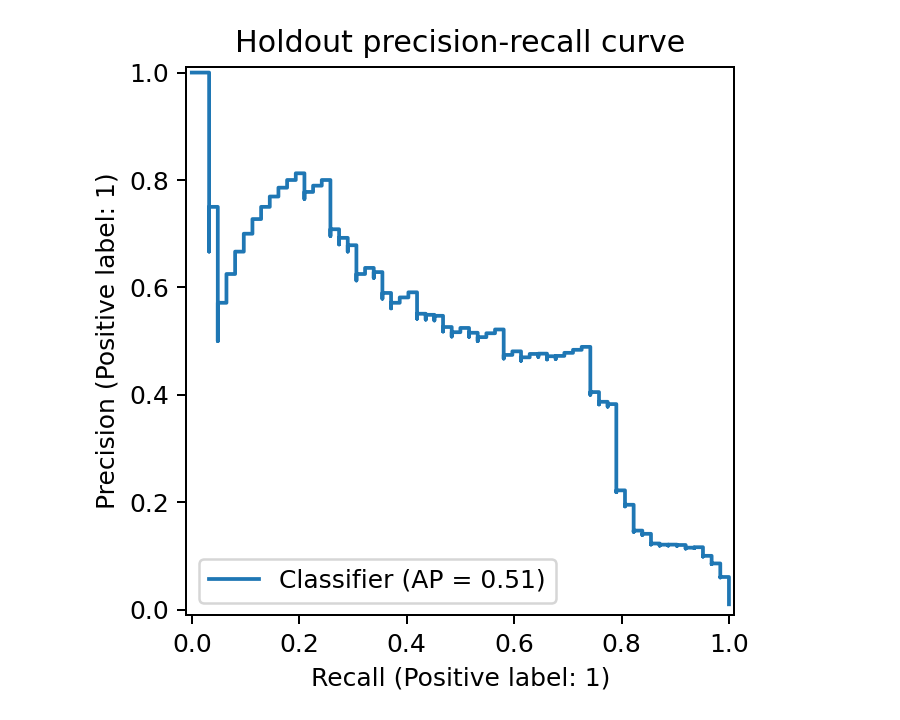

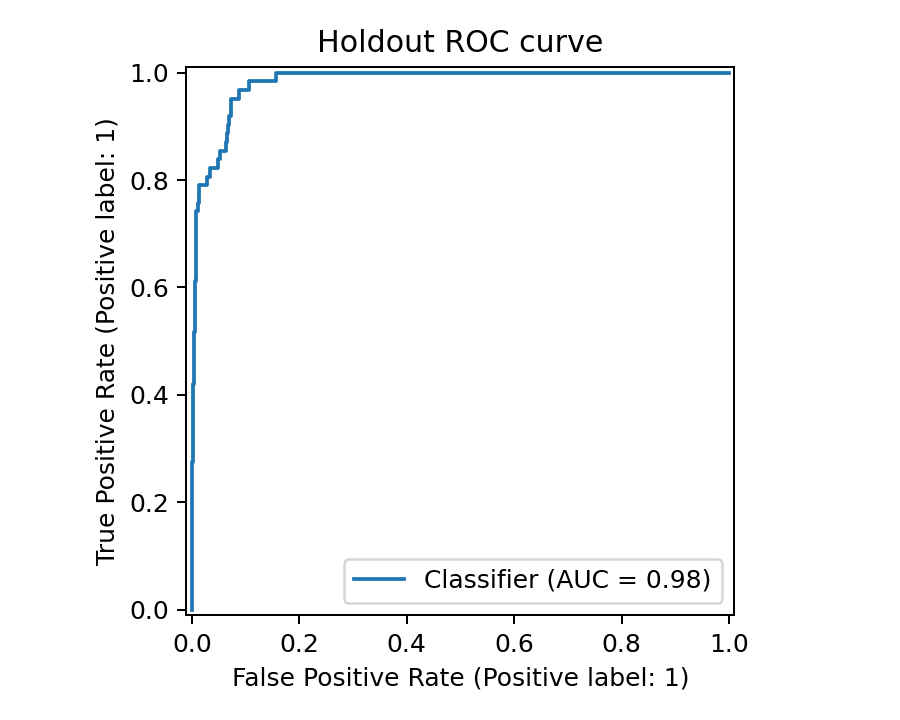

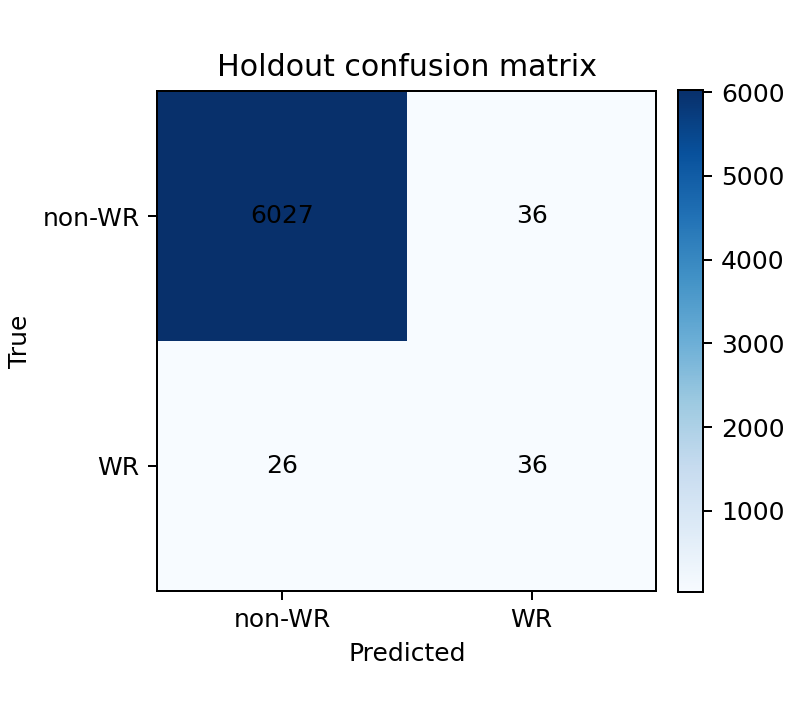

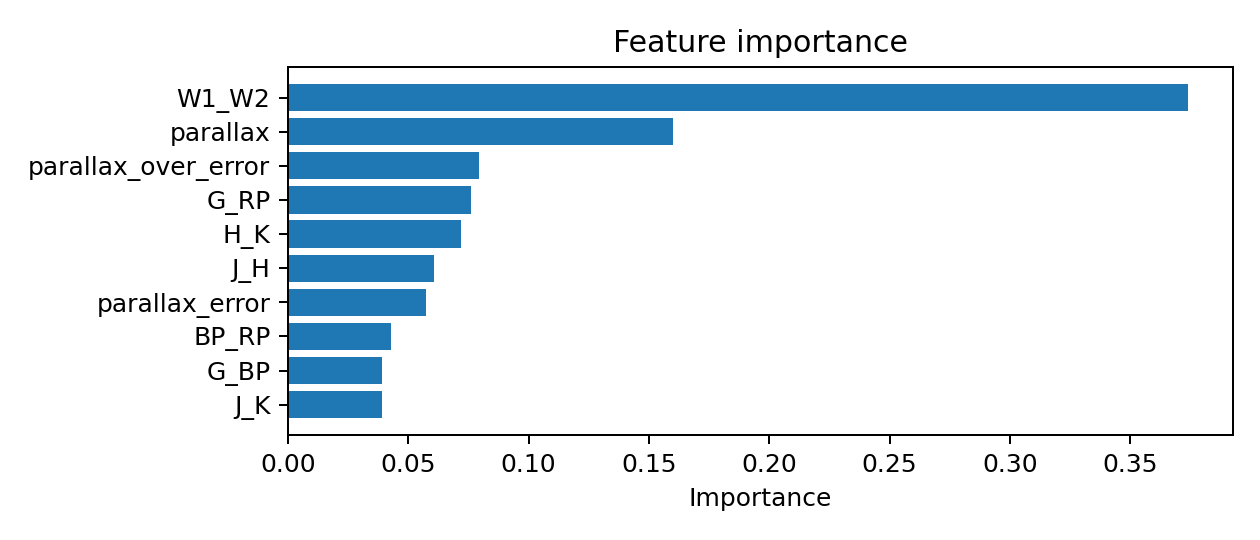

### #2: XGB SMOTE | Strict POE>=2 | +err

Top 100: `31/42` = `73.8%` | AP `0.576` | estado `accepted`

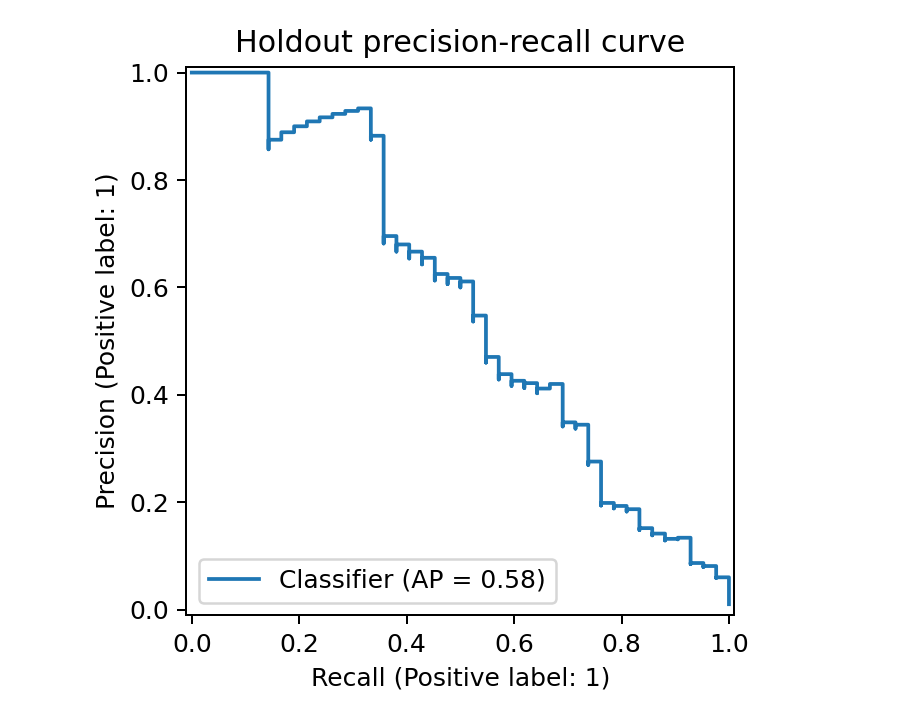

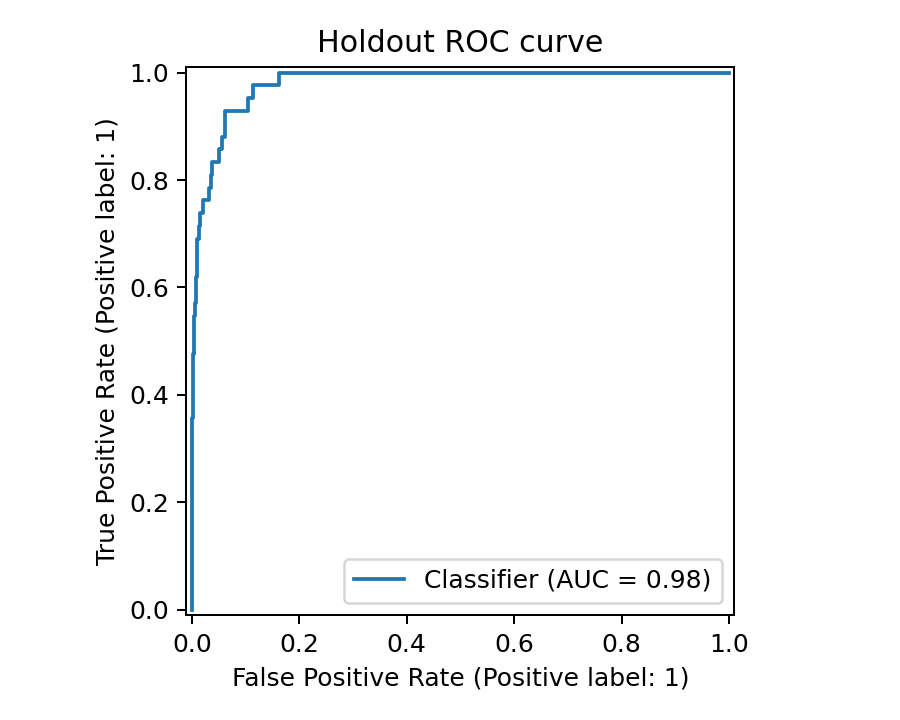

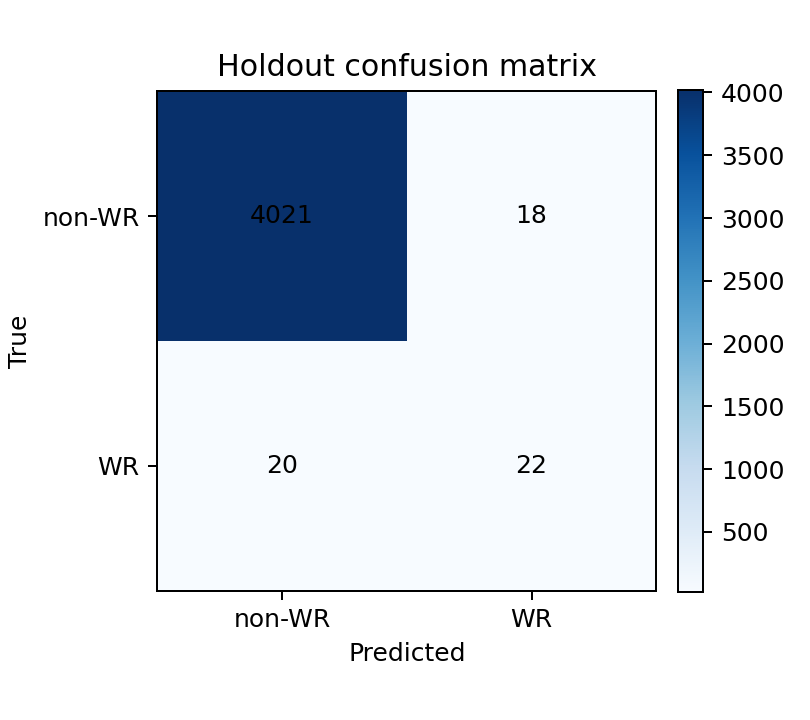

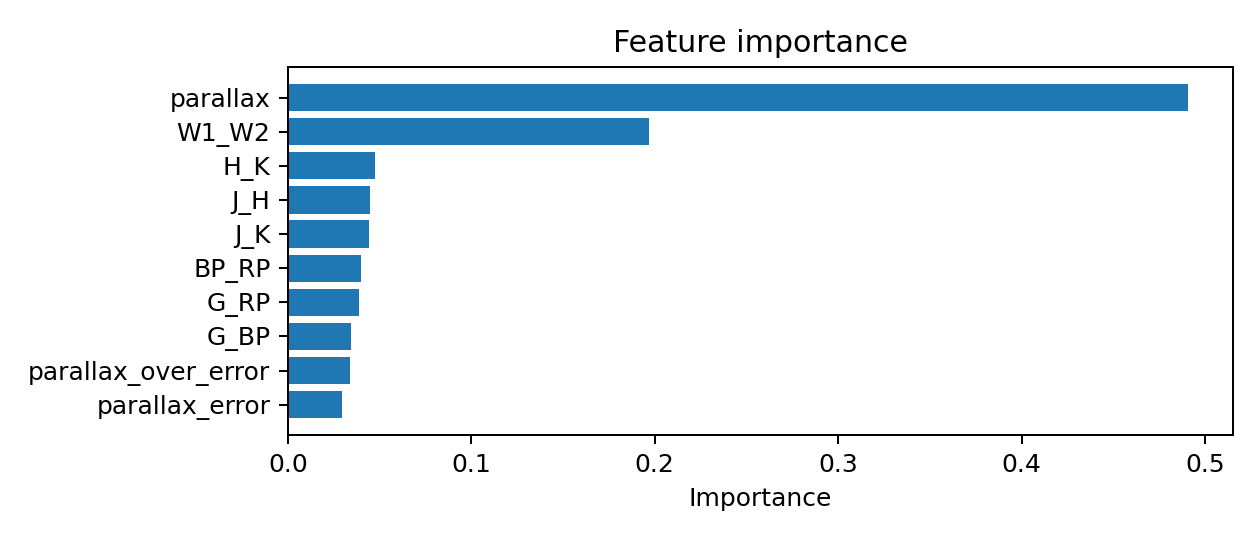

### #3: XGB SMOTE | Strict POE>=3 | +err

Top 100: `27/37` = `73.0%` | AP `0.396` | estado `accepted`

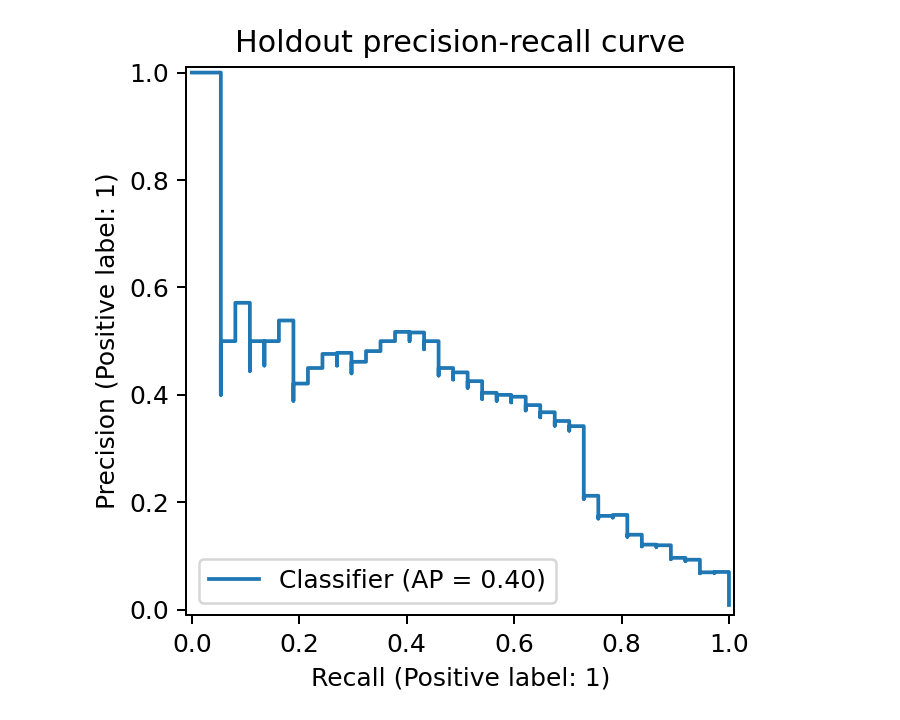

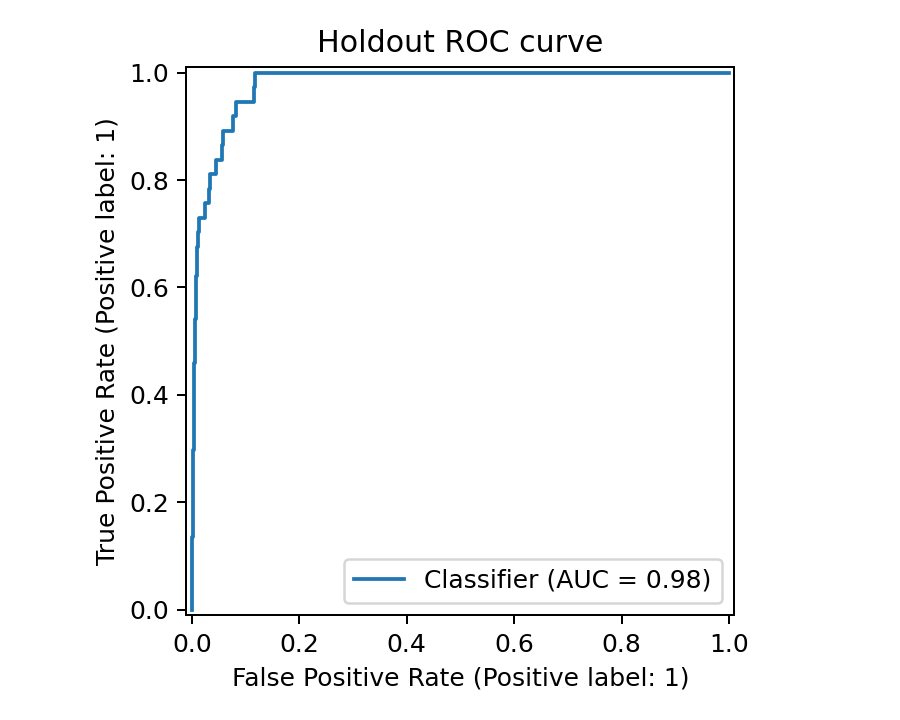

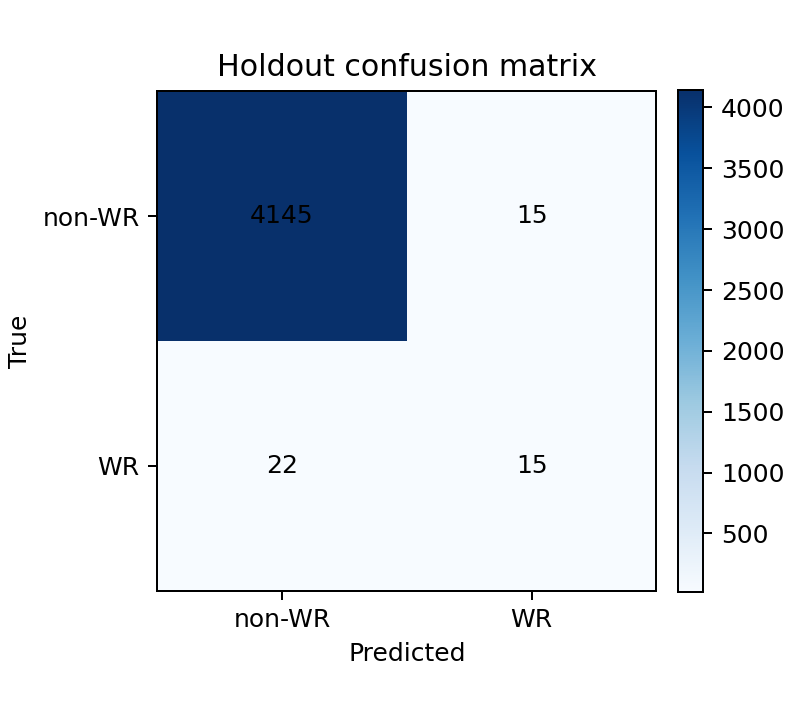

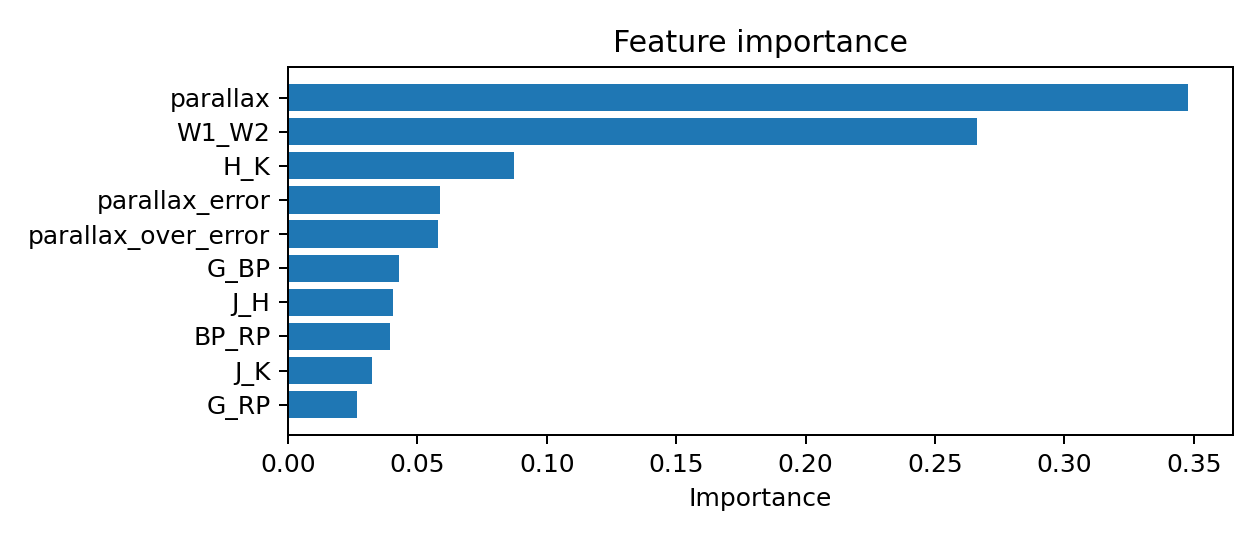

In [ ]:
for idx, row in ranked.head(3).reset_index(drop=True).iterrows():
    display(Markdown(f"### #{idx+1}: {row['model_label']}"))
    display(Markdown(f"Top 100: `{int(row['holdout_wr_at_100'])}/{int(row['wr_holdout'])}` = `{pct(row['holdout_wr_at_100_pct'])}` | AP `{row['holdout_average_precision']:.3f}` | estado `{row['selection_status']}`"))
    for col in ["holdout_pr_curve_path", "holdout_roc_curve_path", "holdout_confusion_matrix_path", "feature_importance_figure_path"]:
        p = ROOT / str(row.get(col, ""))
        if p.exists():
            display(Image(filename=str(p)))
        else:
            display(Markdown(f"No existe `{col}`: `{p}`"))
